# Polar plot
Based on https://github.com/climberlenny/test_openberg/blob/main/toolbox/postprocessing.py

In [1]:
cd ~/work/tutorials/sources/OpenDrift/openberg_july2026

/home/jovyan/work/tutorials/sources/OpenDrift/openberg_july2026


In [2]:
from src.utils import *
from openberg_july2026.src2.utils2 import *
import glob

In [78]:
# Read and subset tracker data
ib = 'iceberg2017b'

#read obs
with xr.open_dataset('./input/merged_obs4.nc') as ds:
    obs = ds.sel(iceberg=ib,trajectory_id=ib) 
    obs_seed = obs.isel(time=(obs.seed_idx==1))

In [113]:
#read sim
file_contain_all = [ib,'topaz','wa']
file_contain_any = ['_']
file_notcontain = ['test','next','6']#['topaz4','glorys','slope','era5','almost','stokes',]
file_l = glob.glob("./results/*.nc")#['./results/juliette_topaz6_topaz4_windglophynrt.nc',]
file_l = [f for f in file_l if all(ff in f for ff in file_contain_all)] #filtering for required keywords
file_l = [f for f in file_l if any(ff in f for ff in file_contain_any)] #filtering for required keywords
file_l = [f for f in file_l if all(ff not in f for ff in file_notcontain)] #filtering for neglected keywords
file_l = file_l#[::-1]

trajs,note = np.arange(obs.time.size*11), False
print(file_l,trajs.size,note)

['./results/iceberg2017b_gebco_topaz4_waverys_windglophyre.nc'] 102949 False


In [114]:
# # Read simulation data
# # # --- Which simulation data for plot? ---
# # file_contain_all = ['_']
# # file_contain_any = ['_']
# # file_notcontain = ['topaz4','glorys','slope','era5','almost','stokes',]
# # file_l = glob.glob("./results/*.nc")#['./results/juliette_topaz6_topaz4_windglophynrt.nc',]
# # file_l = [f for f in file_l if all(ff in f for ff in file_contain_all)] #filtering for required keywords
# # file_l = [f for f in file_l if any(ff in f for ff in file_contain_any)] #filtering for required keywords
# # file_l = [f for f in file_l if all(ff not in f for ff in file_notcontain)] #filtering for neglected keywords
# # #full
# file_l = ['nextsimanfc_glophyanfc_waverys_windglophynrt', 'nextsimanfc_glophyanfc_mfwam_windglophynrt', 'nextsimanfc_glophyanfc_arcmfcwam_windglophynrt', 
#           'nextsimanfc_topaz5_waverys_windglophynrt', 'nextsimanfc_topaz5_mfwam_windglophynrt', 'nextsimanfc_topaz5_arcmfcwam_windglophynrt', 
#           'nextsimanfc_topaz6_topaz5_waverys_windglophynrt', 'nextsimanfc_topaz6_topaz5_mfwam_windglophynrt', 'nextsimanfc_topaz6_topaz5_arcmfcwam_windglophynrt', 
#           'glophyanfc_waverys_windglophynrt', 'topaz5_waverys_windglophynrt', 'topaz6_topaz5_waverys_windglophynrt',]
# #part1,2
# # file_l = ['nextsimanfc_glophyanfc_waverys_windglophynrt', 'nextsimanfc_glophyanfc_mfwam_windglophynrt', 'nextsimanfc_glophyanfc_arcmfcwam_windglophynrt', 
# #           'nextsimanfc_topaz6_topaz5_waverys_windglophynrt', 'nextsimanfc_topaz6_topaz5_mfwam_windglophynrt', 'nextsimanfc_topaz6_topaz5_arcmfcwam_windglophynrt', ]
# #           'nextsimanfc_topaz5_waverys_windglophynrt', 'nextsimanfc_topaz5_mfwam_windglophynrt', 'nextsimanfc_topaz5_arcmfcwam_windglophynrt', 
# #part3
# # file_l = ['glophyanfc_waverys_windglophynrt', 'topaz6_topaz5_waverys_windglophynrt', 'topaz5_waverys_windglophynrt','nextsimanfc_glophyanfc_waverys_windglophynrt']
# file_l = ['./results/juliette_%s_wavedir.nc'%(f) for f in file_l]
# #trajs
# # trajs,note = np.arange(0,10*10+1), 'PART1' #PART1
# # trajs,note = np.arange(11*10,19*10+1), 'PART2' #PART2
# trajs,note = np.arange(20*10,25*10+1), 'PART3' #PART3
# trajs,note = np.arange(0,26*10), 'ALLPARTS'
# file_l,trajs[0],trajs[-1],note

In [115]:
# --- Open all simulation results in one dataset ---
with xr.open_mfdataset(
    file_l,
    combine="nested",
    concat_dim="run",
    parallel=True,
    engine="netcdf4",
    # chunks={'time': -1}
) as simall: 
    simall = simall.assign_coords(run=file_l)  # or any list of labels

In [116]:
simall

<xarray.Dataset> Size: 225MB
Dimensions:                                   (run: 1, trajectory: 176,
                                               time: 7619)
Coordinates:
  * run                                       (run) <U59 236B './results/iceb...
  * trajectory                                (trajectory) int32 704B 0 ... 175
  * time                                      (time) datetime64[ns] 61kB 2017...
Data variables: (12/39)
    status                                    (run, trajectory, time) float64 11MB dask.array<chunksize=(1, 176, 7619), meta=np.ndarray>
    moving                                    (run, trajectory, time) float64 11MB dask.array<chunksize=(1, 176, 7619), meta=np.ndarray>
    age_seconds                               (run, trajectory, time) float32 5MB dask.array<chunksize=(1, 176, 7619), meta=np.ndarray>
    origin_marker                             (run, trajectory, time) float64 11MB dask.array<chunksize=(1, 176, 7619), meta=np.ndarray>
    lon                                       (run, trajectory, time) float32 5MB dask.array<chunksize=(1, 176, 7619), meta=np.ndarray>
    lat                                       (run, trajectory, time) float32 5MB dask.array<chunksize=(1, 176, 7619), meta=np.ndarray>
    ...                                        ...
    sea_water_salinity                        (run, trajectory, time) float32 5MB dask.array<chunksize=(1, 176, 7619), meta=np.ndarray>
    sea_ice_area_fraction                     (run, trajectory, time) float32 5MB dask.array<chunksize=(1, 176, 7619), meta=np.ndarray>
    sea_ice_thickness                         (run, trajectory, time) float32 5MB dask.array<chunksize=(1, 176, 7619), meta=np.ndarray>
    sea_ice_x_velocity                        (run, trajectory, time) float32 5MB dask.array<chunksize=(1, 176, 7619), meta=np.ndarray>
    sea_ice_y_velocity                        (run, trajectory, time) float32 5MB dask.array<chunksize=(1, 176, 7619), meta=np.ndarray>
    land_binary_mask                          (run, trajectory, time) float32 5MB dask.array<chunksize=(1, 176, 7619), meta=np.ndarray>
Attributes: (12/147)
    Conventions:                                                           CF...
    standard_name_vocabulary:                                              CF...
    featureType:                                                           tr...
    title:                                                                 Op...
    summary:                                                               Ou...
    keywords:                                                              tr...
    ...                                                                    ...
    geospatial_lon_units:                                                  de...
    geospatial_lon_resolution:                                             point
    runtime:                                                               0:...
    geospatial_vertical_min:                                               nan
    geospatial_vertical_max:                                               nan
    geospatial_vertical_positive:                                          up

In [117]:
# # --- find trajectories
# # by seeding length
# seedinglengths = np.nanmax(simall.length[0,:,:],axis=1)
# seedinglengths_unq = np.unique(seedinglengths)
# print(seedinglengths_unq)
# seedinglengths_dict = {v: np.where(seedinglengths == v)[0].tolist() for v in seedinglengths_unq}
# trajs = np.array([seedinglengths_dict[sl] for sl in seedinglengths_unq[2:]]).flatten()

# by time
# print(trajs)#, simall.sel(trajectory=trajs).time[np.array([0,-1])].values)#, np.unique(seedinglengths[trajs]))
# # note='wave_only_o300mlength'

In [118]:
# runtrajdict = {#for analysis of part I and II [timestep: 0-10,11-19]
#              'nextsimanfc_glophyanfc_waverys_windglophynrt':np.arange(0,26*10),
#              'nextsimanfc_glophyanfc_mfwam_windglophynrt':np.arange(0,20*10),
#              'nextsimanfc_glophyanfc_arcmfcwam_windglophynrt':np.arange(0,20*10),
#              'nextsimanfc_topaz5_waverys_windglophynrt':np.arange(0,20*10),
#              'nextsimanfc_topaz5_mfwam_windglophynrt':np.arange(0,20*10),
#              'nextsimanfc_topaz5_arcmfcwam_windglophynrt':np.arange(0,20*10),
#              'nextsimanfc_topaz6_topaz5_waverys_windglophynrt':np.arange(0,20*10),
#              'nextsimanfc_topaz6_topaz5_mfwam_windglophynrt':np.arange(0,20*10),
#              'nextsimanfc_topaz6_topaz5_arcmfcwam_windglophynrt':np.arange(0,20*10),
#             #for analysis of part III
#               # 'nextsimanfc_glophyanfc_arcmfcwam_windglophynrt':np.arange(20*10,26*10), #2nd
#              'glophyanfc_waverys_windglophynrt':np.arange(20*10,26*10),
#              'topaz5_waverys_windglophynrt':np.arange(20*10,26*10),
#              'topaz6_topaz5_waverys_windglophynrt':np.arange(20*10,26*10),#maybe change ideces here to matchdifferent counting
#             'nextsim':np.arange(20*10,26*10),
# }
            
# colordict = {#for analysis of part I and II
#              'nextsimanfc_glophyanfc_waverys_windglophynrt':{'col':'orange','alpha':1,'kw':'Glophyanfc'},
#              'nextsimanfc_glophyanfc_mfwam_windglophynrt':{'col':'orange','alpha':0.7,'kw':'Glophyanfc'},
#              'nextsimanfc_glophyanfc_arcmfcwam_windglophynrt':{'col':'orange','alpha':0.4,'kw':'Glophyanfc'},
#              'nextsimanfc_topaz5_waverys_windglophynrt':{'col':'cyan','alpha':1,'kw':'TOPAZ5'},
#              'nextsimanfc_topaz5_mfwam_windglophynrt':{'col':'cyan','alpha':0.7,'kw':'TOPAZ5'},
#              'nextsimanfc_topaz5_arcmfcwam_windglophynrt':{'col':'cyan','alpha':0.4,'kw':'TOPAZ5'},
#              'nextsimanfc_topaz6_topaz5_waverys_windglophynrt':{'col':'green','alpha':1,'kw':'TOPAZ6+5'},
#              'nextsimanfc_topaz6_topaz5_mfwam_windglophynrt':{'col':'green','alpha':0.7,'kw':'TOPAZ6+5'},
#              'nextsimanfc_topaz6_topaz5_arcmfcwam_windglophynrt':{'col':'green','alpha':0.4,'kw':'TOPAZ6+5'},
#             #for analysis of part III
#              'nextsim':{'col':'red','alpha':1,'kw':'neXtSIM'},
#              'glophyanfc_waverys_windglophynrt':{'col':'orange','alpha':1,'kw':'Glophyanfc'},
#              'topaz5_waverys_windglophynrt':{'col':'cyan','alpha':1,'kw':'TOPAZ5'},
#              'topaz6_topaz5_waverys_windglophynrt':{'col':'green','alpha':1,'kw':'TOPAZ6+5'},
# }

legenddict_full = {              
            'neXtSIM':{'col':'red','alpha':1},
            'GLORYS':{'col':'darkblue','alpha':1},
            'Glophyanfc':{'col':'orange','alpha':1},
              'TOPAZ4':{'col':'purple','alpha':1},
              'TOPAZ5':{'col':'cyan','alpha':1},
              'TOPAZ6+5':{'col':'green','alpha':1},
              'WAVERYS (alpha=1)':{'col':'green','alpha':1},
              'MFWAM (alpha=0.7)':{'col':'green','alpha':0.7},
              'ARCMFCWAM (alpha=0.4)':{'col':'green','alpha':0.4},
             }
legenddict = {l:v for l,v in legenddict_full.items() for f in file_l if l.lower() in f }

colordict = dict.fromkeys([f.split('/')[-1][:-3] for f in file_l])
runtrajdict = dict.fromkeys([f.split('/')[-1][:-3] for f in file_l],np.arange(obs.time.size*11))
for f in colordict:
    for l in legenddict:
        colordict[f]={'col':legenddict[l]['col'], 'alpha':1, 'kw':l}
colordict

{'iceberg2017b_gebco_topaz4_waverys_windglophyre': {'col': 'purple',
  'alpha': 1,
  'kw': 'TOPAZ4'}}

In [119]:
# --- Processing before plotting ---
# Create obs-sim pairs by a) looking for the cloosest observation time for every simulation time,
# b) subset (both datasets) to 6hourly or daily frequnecy, then as a),
# # or c) looking for closest sim in obs.time.
sim = simall
# sim = simall.sel(trajectory=trajs)
# # a)Selects the nearest times in obs for every sim.time whihc is hourly
# obs_simfreq = obs.sel(time=sim.time, method="nearest") 
# # b)
# sim_daily = sim.resample(time="1D").first() #.mean() 
# sim_6h = sim.sel(time=sim.time.dt.hour.isin([0, 6, 12, 18]))
# sim_6h.time
# obs_dailysimfreq = obs.sel(time=sim_daily.time, method="nearest") 
# # c) looking for closest sim in obs.time.
# sim_obstime = sim.sel(time=obs.time, method="nearest") 
# sim_obstime.time
# d) looking for closest sim in subset of obs.time (e.g. daily)
days = obs.time.dt.floor("D")
days2 = np.arange(obs_seed.time.dt.floor("D")[0].values,
                  obs_seed.time.dt.floor("D")[-1].values+np.timedelta64(str(obs.seed_freq.values)[:-1],str(obs.seed_freq.values)[-1]),
                  dtype='datetime64[D]')
idx = [
    np.where(days == np.datetime64(d))[0][0]
    for d in days2
    if (days == np.datetime64(d)).any()
]
obs_subtime = obs.isel(time=idx)
sim_obssubtime = sim.sel(time=obs_subtime.time, method="nearest") 

#or daily averages?
#Cut off from 5 Dec on as no sim results!

sim_sub = sim_obssubtime
obs_sub = obs_subtime

In [120]:
from scipy.spatial.distance import pdist

def polar_to_cartesian(theta, r):
    """Convert polar coordinates to Cartesian coordinates."""
    x = r * np.cos(theta)
    y = r * np.sin(theta)
    return x, y

def create_density_grid(points, grid_size=100, c=0.5):
    points = points[~np.isnan(points).any(axis=1)]
    # Calculer la distance moyenne entre les points
    d_avg = calculate_average_distance(points) + 1
    # Déterminer sigma en fonction de d_avg et du paramètre c
    sigma = c * d_avg

    # Déterminer les limites de la grille
    x_min, x_max = min(points[:, 0]) - 2 * sigma, max(points[:, 0]) + 2 * sigma
    y_min, y_max = min(points[:, 1]) - 2 * sigma, max(points[:, 1]) + 2 * sigma

    # Créer une grille de coordonnées
    x = np.linspace(x_min, x_max, grid_size)
    y = np.linspace(y_min, y_max, grid_size)
    X, Y = np.meshgrid(x, y)

    # Initialiser la grille de densité
    density_grid = np.zeros((grid_size, grid_size))

    # Nombre de points
    N = len(points)

    # Appliquer la distribution gaussienne à chaque point
    for point in points:
        dx = X - point[0]
        dy = Y - point[1]
        r = np.sqrt(dx**2 + dy**2)
        density_grid += gaussian_kernel(r, sigma) / N

    return X, Y, density_grid

def calculate_average_distance(points):
    if len(points) > 1000:
        distances = pdist(points[::50])
    else:
        distances = pdist(points)
    d_avg = np.mean(distances)
    return d_avg
    
def gaussian_kernel(r, sigma):
    return np.exp(-(r**2) / (2 * sigma**2)) / (2 * np.pi * sigma**2)

def find_contour_levels(density_grid, percentages):
    sorted_density = np.sort(density_grid.ravel())[::-1]
    cumsum_density = np.cumsum(sorted_density)
    total_density = cumsum_density[-1]
    levels = [
        sorted_density[np.searchsorted(cumsum_density, p * total_density)]
        for p in percentages
    ]
    levels.sort()  # S'assurer que les niveaux sont dans l'ordre croissant
    return levels



In [121]:
import pyproj
geod = pyproj.Geod(ellps="WGS84")
url_letters, note_letters, fileending_letters = 19,8,3


#
# for runn,run in enumerate(sim_sub.run):
#     # print(runn,run.run.values)
#     inputdata = str(run.run.values)[url_letters:-(note_letters+fileending_letters)]
#     sub_run = sim_sub.sel(run=run)
#     inputtraj = np.intersect1d(sub_run.trajectory.values,runtrajdict[inputdata])
#     inputtrajnot = np.setdiff1d(sub_run.trajectory.values,runtrajdict[inputdata])
#     sub_run = sub_run.sel(trajectory=inputtraj)
#     # print(inputdata, inputtrajnot)

    
#     da = sim_sub
    
#     mask = ~(
#         (da.run == run) &
#         (da.trajectory.isin(inputtrajnot))
#     )
    
#     sim_sub = da.where(mask, np.nan)


# observation = ref
azimuth_alpha, a2, distance0 = geod.inv(
    obs_sub.lon[:-1],obs_sub.lat[:-1],obs_sub.lon[1:],obs_sub.lat[1:])
dt = np.diff(obs_sub.time) / np.timedelta64(1, "s")  #individual timesteps between the points
vel0 = distance0 / dt #distance/seconds
vel0

# simulation results of all together -> density
azimuth_betha, a2, distance1 = geod.inv(
    sim_sub.lon[:,:,:-1],sim_sub.lat[:,:,:-1],sim_sub.lon[:,:,1:],sim_sub.lat[:,:,1:])
dt = np.diff(sim_sub.time) / np.timedelta64(1, "s") #individual timesteps between the points
vel1 = distance1 / dt #distance/seconds

# calculate the coordinates in the polar plot
# THETA = np.array((azimuth_betha - azimuth_alpha + 360) % 360) #old
THETA = (azimuth_betha - azimuth_alpha + 180) % 360 - 180
R = np.where(vel0>0,vel1 / vel0,np.nan) # if vel0 > 0 else 0
R = np.where((R <= 3)&(R > 0.0),R,np.nan) #correction for outliers and non-drifting icebergs, &(R > 0.0)

#
x, y = polar_to_cartesian(np.pi / 2 - np.radians(THETA[R <= 3]), R[R <= 3]) #used in scatterplot
x_insiders_all = np.nanmean(x)
y_insiders_all = np.nanmean(y)
# --- convert centroid BACK to polar (for text output) ---
r_avg_insiders_all = np.sqrt(x_insiders_all**2 + y_insiders_all**2)
# r_avg_insiders_all = np.nanmean(R[R <= 3])
theta_plot = np.arctan2(y_insiders_all, x_insiders_all)
# convert back to your angle convention (0° = north)
theta_avg_insiders_all = np.degrees(np.pi/2 - theta_plot)

print(np.nanmean(R),np.nanmean(THETA))
print(r_avg_insiders_all,theta_avg_insiders_all)

0.7655637549730239 -12.509038034499653
0.5157802310078038 -13.770243069034896


/tmp/ipykernel_64622/399462887.py:43: RuntimeWarning: divide by zero encountered in divide
  R = np.where(vel0>0,vel1 / vel0,np.nan) # if vel0 > 0 else 0
/tmp/ipykernel_64622/399462887.py:43: RuntimeWarning: invalid value encountered in divide
  R = np.where(vel0>0,vel1 / vel0,np.nan) # if vel0 > 0 else 0


/tmp/ipykernel_64622/3575974917.py:30: RuntimeWarning: divide by zero encountered in divide
  R = np.where(vel0>0,vel1 / vel0,np.nan) # if vel0 > 0 else 0
/tmp/ipykernel_64622/3575974917.py:30: RuntimeWarning: invalid value encountered in divide
  R = np.where(vel0>0,vel1 / vel0,np.nan) # if vel0 > 0 else 0


iceberg2017b_gebco_topaz4_waverys_windglophyre 0 175 0 175


/tmp/ipykernel_64622/3575974917.py:143: RuntimeWarning: divide by zero encountered in divide
  R = np.where(vel0>0,vel1 / vel0,np.nan) # if vel0 > 0 else 0
/tmp/ipykernel_64622/3575974917.py:143: RuntimeWarning: invalid value encountered in divide
  R = np.where(vel0>0,vel1 / vel0,np.nan) # if vel0 > 0 else 0


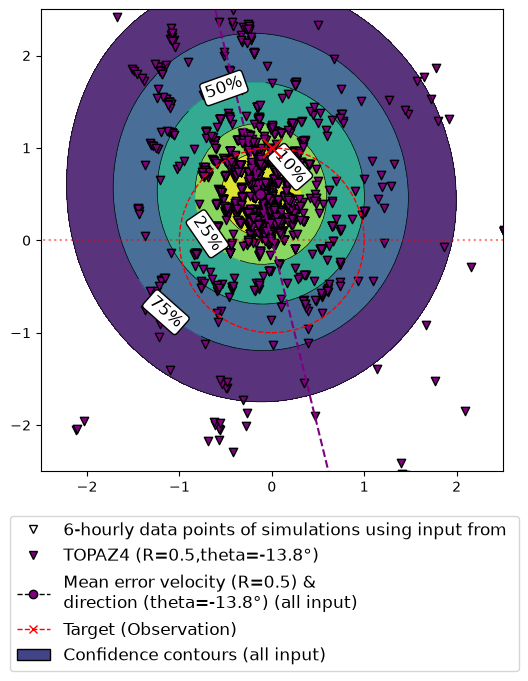

In [122]:
import pyproj
from scipy.stats import circmean
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
geod = pyproj.Geod(ellps="WGS84")

# cmap = plt.get_cmap('tab20')  # or 'viridis', 'plasma', etc.
# col = cmap(np.linspace(0, 1, 20))[::2]#20 colors
url_letters, name_letters,note_letters, fileending_letters = 10,14,0,3
means_save = {}
spread_save = {}


# observation = ref
azimuth_alpha, a2, distance0 = geod.inv(
    obs_sub.lon[:-1],obs_sub.lat[:-1],obs_sub.lon[1:],obs_sub.lat[1:])
dt = np.diff(obs_sub.time) / np.timedelta64(1, "s")  #individual timesteps between the points
vel0 = distance0 / dt #distance/seconds
vel0

# simulation results of all together -> density
azimuth_betha, a2, distance1 = geod.inv(
    sim_sub.lon[:,:,:-1],sim_sub.lat[:,:,:-1],sim_sub.lon[:,:,1:],sim_sub.lat[:,:,1:])
dt = np.diff(sim_sub.time) / np.timedelta64(1, "s") #individual timesteps between the points
vel1 = distance1 / dt #distance/seconds

# calculate the coordinates in the polar plot
# THETA = np.array((azimuth_betha - azimuth_alpha + 360) % 360) #old
THETA = (azimuth_betha - azimuth_alpha + 180) % 360 - 180 #all
R = np.where(vel0>0,vel1 / vel0,np.nan) # if vel0 > 0 else 0
R = np.where((R <= 3)&(R > 0.0),R,np.nan) #correction for outliers and non-drifting icebergs

# #average meassures (incl outsiders)
# r_avg_with_outsiders = np.nanmean(R)
# theta_avg_with_outsiders = circmean(THETA[~np.isnan(THETA)])
# print(theta_avg_with_outsiders, r_avg_with_outsiders, np.nanmax(R))
# outsiders = (R > 3).sum() / len(R) * 100#calc insiders and gridded densities:
# x_outsiders, y_outsiders = polar_to_cartesian(
#     np.pi / 2 - np.radians(theta_avg_with_outsiders), r_avg_with_outsiders)

#calc average of insiders (old methd)
# x, y = polar_to_cartesian(np.pi / 2 - np.radians(THETA[R <= 3]), R[R <= 3]) #used in scatterplot
# r_avg_insiders_all = np.mean(R[R <= 3])
# # theta_avg_insiders_all = circmean(THETA[R <= 3], high=360, low=0)
# theta_avg_insiders_all = circmean(THETA[R <= 3], high=180, low=-180)
# x_insiders_all, y_insiders_all = polar_to_cartesian(
#     np.pi / 2 - np.radians(theta_avg_insiders_all), r_avg_insiders_all)

# #new vectorised method to get averag theta and r
# r = R[R <= 3]
# angles = np.radians(THETA[R <= 3])
# theta_plot = np.pi/2 - angles
# # x = r * np.cos(theta_plot) #used in scatterplot
# # y = r * np.sin(theta_plot)
# # x_insiders_all, y_insiders_all = np.mean(x),np.mean(y) #used for plotting average
# # theta_avg_insiders_all = np.arctan2(np.mean(y), np.mean(x)) #used as text output
# # r_avg_insiders_all = np.sqrt(np.mean(x)**2 + np.mean(y)**2)
# #other new method
# x = np.cos(theta_plot)
# y = np.sin(theta_plot)
# x_insiders_all, y_insiders_all = np.mean(x),np.mean(y) #used for plotting average
# theta_avg_insiders_all = np.arctan2(np.mean(np.sin(angles)),
#                        np.mean(np.cos(angles)))

# --- compute centroid in cartesian space ---
x, y = polar_to_cartesian(np.pi / 2 - np.radians(THETA[R <= 3]), R[R <= 3]) #used in scatterplot
x_insiders_all = np.nanmean(x)
y_insiders_all = np.nanmean(y)
# --- convert centroid BACK to polar (for text output) ---
r_avg_insiders_all = np.sqrt(x_insiders_all**2 + y_insiders_all**2)
# r_avg_insiders_all = np.nanmean(R[R <= 3])
theta_plot = np.arctan2(y_insiders_all, x_insiders_all)
# convert back to your angle convention (0° = north)
theta_avg_insiders_all = np.degrees(np.pi/2 - theta_plot)
# normalize to [-180, 180]
theta_avg_insiders_all = (theta_avg_insiders_all + 180) % 360 - 180
means_save['all'] = [np.round(vals,1) for vals in (r_avg_insiders_all,theta_avg_insiders_all)]
spread_save['all'] = [np.round(vals,1) 
                      for vals in (np.nanmax(R) - np.nanmin(R),np.nanmax(THETA) - np.nanmin(THETA),np.nanpercentile(R, 90) - np.nanpercentile(R, 10),np.nanpercentile(THETA, 90) - np.nanpercentile(THETA, 10))] #range as in max-min and IQR range (from 90 to 10%)

#density grid
grid_size = 100
percentages = [0.9, 0.75, 0.5, 0.25, 0.1, 0]
points_insiders = np.vstack((x, y)).T
X, Y, density_grid = create_density_grid(points_insiders, grid_size, c=0.5)
levels = find_contour_levels(density_grid, percentages)

fig, ax = plt.subplots(figsize=(6, 6))
contourf = ax.contourf(
    X,
    Y,
    density_grid,
    levels=levels,
    cmap="viridis",
    alpha=0.9,
)
contour = ax.contour(
    X,
    Y,
    density_grid,
    levels=levels,
    colors="k",
    linewidths=(0.5,),
)
clabels = ax.clabel(
    contour,
    inline=True,
    fontsize=12,
    fmt={level: f"{int(p*100)}%" for level, p in zip(levels, percentages)},
)
## Customize clabels
for txt in clabels:
    txt.set_bbox(
        dict(facecolor="white", edgecolor=txt.get_color(), boxstyle="round,pad=0.2")
    )
    txt.set_color("black")

# ax.scatter(
#     x, y, alpha=0.5, marker="v", color='w', edgecolor="k", label="6-hourly Data points \nof simulations using input from"
# )


#simulation reuslts per run seperately
for runn,run in enumerate(sim_sub.run):
    # print(runn,run.run.values)
    inputdata = str(run.run.values)[url_letters:-(note_letters+fileending_letters)]
    sub_run = sim_sub.sel(run=run)
    inputtraj = np.intersect1d(sub_run.trajectory.values,runtrajdict[inputdata])
    sub_run = sub_run.sel(trajectory=inputtraj)
    print(inputdata,inputtraj[0],inputtraj[-1],sub_run.trajectory.values[0],sub_run.trajectory.values[-1])
    
    # col_run = col[runn]
    col_run = colordict['nextsim']['col'] if np.logical_and(inputdata=='nextsimanfc_glophyanfc_waverys_windglophynrt',np.any(np.isin(np.arange(10*20,26*10,1), trajs))) else colordict[inputdata]['col']

    # simulation
    azimuth_betha, a2, distance1 = geod.inv(
        sub_run.lon[:,:-1],sub_run.lat[:,:-1],sub_run.lon[:,1:],sub_run.lat[:,1:])
    dt = np.diff(sub_run.time) / np.timedelta64(1, "s") #individual timesteps between the points
    vel1 = distance1 / dt #distance/seconds
    
    # calculate the coordinates in the polar plot
    THETA = np.array((azimuth_betha - azimuth_alpha + 360) % 360) #indv
    R = np.where(vel0>0,vel1 / vel0,np.nan) # if vel0 > 0 else 0
    R = np.where((R <= 3)&(R > 0.0),R,np.nan) #correction for outliers and non-drifting icebergs
    
    # #average meassures (incl outisders):
    # r_avg_with_outsiders = np.nanmean(R)
    # theta_avg_with_outsiders = circmean(THETA[~np.isnan(THETA)])
    # print(theta_avg_with_outsiders, r_avg_with_outsiders, np.nanmax(R))
    # outsiders = (R > 3).sum() / len(R) * 100
    # x_outsiders, y_outsiders = polar_to_cartesian(
    # np.pi / 2 - np.radians(theta_avg_with_outsiders), r_avg_with_outsiders)
    
    # # insiders and means (Old)
    # x, y = polar_to_cartesian(np.pi / 2 - np.radians(THETA[R <= 3]), R[R <= 3])
    # r_avg_insiders = np.mean(R[R <= 3])
    # theta_avg_insiders = circmean(THETA[R <= 3], high=360, low=0)
    # x_insiders, y_insiders = polar_to_cartesian(
    #     np.pi / 2 - np.radians(theta_avg_insiders), r_avg_insiders)
    # means_save[run.item()] = [r_avg_insiders,theta_avg_insiders]
    # insiders and means (new)
    x, y = polar_to_cartesian(np.pi / 2 - np.radians(THETA[R <= 3]), R[R <= 3]) #used in scatterplot
    x_insiders = np.mean(x)
    y_insiders = np.mean(y)
    r_avg_insiders = np.sqrt(x_insiders**2 + y_insiders**2)     # r_avg_insiders_all = np.mean(R[R <= 3])
    theta_plot = np.arctan2(y_insiders, x_insiders)
    theta_avg_insiders = np.degrees(np.pi/2 - theta_plot)
    theta_avg_insiders = (theta_avg_insiders + 180) % 360 - 180
    means_save[run.item()] = [np.round(vals,1) for vals in (r_avg_insiders,theta_avg_insiders)]
    spread_save[run.item()] = [np.round(vals,1)
                               for vals in (np.nanmax(R) - np.nanmin(R),np.nanmax(THETA) - np.nanmin(THETA),
                                            np.nanpercentile(R, 90) - np.nanpercentile(R, 10),np.nanpercentile(THETA, 90) - np.nanpercentile(THETA, 10))] #range as in max-min and IQR range (from 90 to 10%)

    ax.scatter(
        x, y, alpha=colordict[inputdata]['alpha'], marker="v", color=col_run, edgecolor="k", 
        label=f"{run.item()[19:-3]} \nmean (R={np.round(r_avg_insiders,1)},theta={np.round(theta_avg_insiders,1) if theta_avg_insiders<180 else np.round(theta_avg_insiders-360,1)}°)"
    )
    ax.scatter(
        x_insiders,
        y_insiders,
        marker="o",
        s=50,
        c=col_run,
        alpha=colordict[inputdata]['alpha'],edgecolor='k',
        # label=f"Mean (R={np.round(r_avg_insiders,1)},theta={np.round(theta_avg_insiders,1) if theta_avg_insiders<180 else np.round(theta_avg_insiders-360,1)}°)",
        zorder=30,
    )

    ax.plot(
        np.linspace(-3, 3, 100),
        np.tan(np.pi / 2 - np.deg2rad(theta_avg_insiders)) * np.linspace(-3, 3, 100),
        color=col_run,alpha=colordict[inputdata]['alpha'],
        linestyle="--",
        # label=f"average deviation : {np.round(theta_avg_insiders,1) if theta_avg_insiders<180 else np.round(theta_avg_insiders-360,1)}°",
    )
    # print(inputdata,f"Mean (R={np.round(r_avg_insiders,1)},theta={np.round(theta_avg_insiders,1) if theta_avg_insiders<180 else np.round(theta_avg_insiders-360,1)}°)")

#all simulations again
if len(file_l)>1:
    ax.scatter(
        x_insiders_all,
        y_insiders_all,
        marker="o",
        s=50,
        facecolor='w',edgecolor='k',
        # label=f"mean without ouliers (R={np.round(r_avg_insiders,1)},theta={np.round(theta_avg_insiders,1) if theta_avg_insiders<180 else np.round(theta_avg_insiders-360,1)}°)",
        label=f"Mean error velocity (R={np.round(r_avg_insiders_all,1)})",
        zorder=30,
    )
    # print('all',f"Mean error velocity (R={np.round(r_avg_insiders_all,1)}) & direction (theta={np.round(theta_avg_insiders_all,1) if theta_avg_insiders_all<180 else np.round(theta_avg_insiders_all-360,1)}°) (all input)")
    ax.plot(
        np.linspace(-3, 3, 100),
        np.tan(np.pi / 2 - np.deg2rad(theta_avg_insiders_all)) * np.linspace(-3, 3, 100),
        color="k",
        linestyle="--",
        label=f"Mean error direction (theta={np.round(theta_avg_insiders_all,1) if theta_avg_insiders_all<180 else np.round(theta_avg_insiders_all-360,1)}°)" #f"average deviation : {np.round(theta_avg_insiders,1) if theta_avg_insiders<180 else np.round(theta_avg_insiders-360,1)}°",
    )
    
#other plots things
ax.scatter(0, 1, marker="x", s=200, c="r", label="Target", zorder=20)
ax.hlines(0, xmin=-5, xmax=5, linestyle=":", color="r", alpha=0.5)
ax.set_xlim([-2.5, 2.5])
ax.set_ylim([-2.5, 2.5])
# ax.set_xlim([-3.5, 3.5])
# ax.set_ylim([-3.5, 3.5])
circle1 = plt.Circle(
    (0, 0), 1, edgecolor="r", linestyle="--", fc=None, fill=False, zorder=30
)
ax.add_patch(circle1)
plt.gca().set_aspect(
    "equal", adjustable="box"
)  # Set aspect ratio to make it look polar
# ax.set_title(note)
#legend
# fig.legend(fontsize=12)
legend_elements = [Line2D([0], [0],linestyle='-', color='w', marker='v', markerfacecolor='w',markeredgecolor='k', lw=1,
                          label=f"6-hourly data points of simulations using input from "),]
# legend_elements = legend_elements+[Line2D([0], [0],linestyle='-', color='w', marker='v', markerfacecolor=col[runn],markeredgecolor='k', lw=1,
#                           label=f"{run.item()[19:-3].replace('_',', ').title()} mean error (R={np.round(means_save[run.item()][0],1)},theta={np.round(means_save[run.item()][1],1) if means_save[run.item()][1]<180 else np.round(means_save[run.item()][1]-360,1)}°)") for runn,run in enumerate(sim_sub.run)]

legend_elements = legend_elements+[#Line2D([0], [0],linestyle='-', color=legenddict[el]['col'],alpha=legenddict[el]['alpha'], lw=1, label=el) for el in legenddict]
                                Line2D([0], [0],linestyle='-', color='w', markerfacecolor=legenddict[el]['col'],alpha=legenddict[el]['alpha'], marker='v',markeredgecolor='k', lw=1,
                                       label=f"{el} (R={np.round(means_save[run.item()][0],1)},theta={np.round(means_save[run.item()][1],1) if means_save[run.item()][1]<180 else np.round(means_save[run.item()][1]-360,1)}°)") for el in legenddict]
legend_elements = legend_elements+[                      
                  Line2D([0], [0],linestyle='--', color='k',marker='o',markerfacecolor='w' if len(file_l)>1 else col_run,markeredgecolor='k', lw=1,
                         label=f"Mean error velocity (R={np.round(r_avg_insiders_all,1)}) & \ndirection (theta={np.round(theta_avg_insiders_all,1) if theta_avg_insiders_all<180 else np.round(theta_avg_insiders_all-360,1)}°) (all input)")]
legend_elements = legend_elements+[Line2D([0], [0],linestyle='--', color='r',marker='x', lw=1,label='Target (Observation)'),
                  Patch(facecolor=plt.colormaps['viridis'](0.2), edgecolor='k',label='Confidence contours (all input)'),
                  ]
leg = fig.legend(handles=legend_elements,fontsize=12,#,ncol=len(legend_elements0+legend_elements2), columnspacing=0.6,labelspacing=0.3,loc='center',bbox_to_anchor=bbox_dict[kw][0])
                   loc='upper center', bbox_to_anchor=(0.5,0.05))
                   # loc='center left', bbox_to_anchor=(0.9,0.5))

if note!=False: plt.savefig('./results/analysis_polarplot_%s.png'%(note), bbox_inches="tight", dpi=400)
plt.show()

In [111]:
note,means_save

(False,
 {'all': [np.float64(0.4), np.float64(-13.8)],
  './results/iceberg2017b_gebco_nextsimre_topaz4_windglophyre.nc': [np.float64(0.4),
   np.float64(-13.8)]})

In [112]:
# Plot legend seperately

# fig,ax = plt.subplots(1,1,figsize=(5,5))
# legend_elements = []
# legend_elements = legend_elements+[                      
#                   Line2D([0], [0],linestyle='--', color='r',marker='x', lw=1,label='Target (Observation)'),
#                   Line2D([0], [0],linestyle='--', color='k',marker='o',markerfacecolor='w',markeredgecolor='k', lw=1,
#                          label=f"Mean error velocity (R, theta)"),#(R={np.round(r_avg_insiders_all,1)}) & \ndirection (theta={np.round(theta_avg_insiders_all,1) if theta_avg_insiders_all<180 else np.round(theta_avg_insiders_all-360,1)}°) (all input)"),
#                   Patch(facecolor=plt.cm.get_cmap('viridis')(0.2), edgecolor='k',label='Confidence contours (all input)'),
#                   ]
# legend_elements = legend_elements+[Line2D([0], [0],linestyle='-', color='w', marker='v', markerfacecolor='w',markeredgecolor='k', lw=1,label='6-hourly data points from \nsimulations with input by:',),]
#                    # Line2D([0], [0],linestyle='-', color='w', lw=1,label='simulations with input by:'),       ]

# # legend_elements = [Line2D([0], [0],linestyle='-', color='w', marker='v', markerfacecolor='w',markeredgecolor='k', lw=1,
# #                           label=f"6-hourly data points of simulations using input from "),]
# # legend_elements = legend_elements+[Line2D([0], [0],linestyle='-', color='w', marker='v', markerfacecolor=col[runn],markeredgecolor='k', lw=1,
# #                           label=f"{run.item()[19:-3].replace('_',', ').title()} mean error (R={np.round(means_save[run.item()][0],1)},theta={np.round(means_save[run.item()][1],1) if means_save[run.item()][1]<180 else np.round(means_save[run.item()][1]-360,1)}°)") for runn,run in enumerate(sim_sub.run)]

# legend_elements = legend_elements+[Line2D([0], [0],linestyle='-', color='w', marker='v', markerfacecolor=legenddict[el]['col'],markeredgecolor='k',alpha=legenddict[el]['alpha'], lw=1, label=el) for el in legenddict]

# leg = fig.legend(handles=legend_elements,fontsize=12,loc='center',ncol=3)#,ncol=len(legend_elements0+legend_elements2),                  columnspacing=0.6,labelspacing=0.3,loc='center',bbox_to_anchor=bbox_dict[kw][0])
#                    # loc='upper center', bbox_to_anchor=(0.5,0.05))
#                    # loc='center left', bbox_to_anchor=(0.9,0.5))

# ax.axis('off')
# plt.savefig('./results/analysis_polarplot_legend.png', bbox_inches="tight", dpi=400)
# plt.show()